### The Middleware are hooks

#Summarization middleware

In [2]:
from langchain.agents import middleware,create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [7]:
agent=create_agent(model=model,checkpointer=InMemorySaver(),
                    middleware=[
                        SummarizationMiddleware(
                            model=model,
                            trigger=("messages",10),
                            keep=  ("messages",4)
                            )
                    ]
)

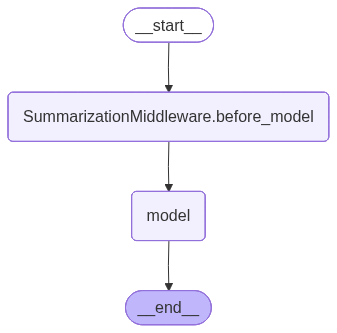

In [8]:
agent

In [9]:
config={"configurable":{"thread_id":"test1"}}

In [12]:
question=[
    "what is 2+2",
    "what is 10*5",
    "what is 3*3",
    "what is 15-7",
    "what is 4*4",
    "who are you"
]

In [13]:
for q in question:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"messages:{response}")
    print(f"messages:{len(response['messages'])}")

messages:{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nThe user\'s primary goal is to get answers to basic arithmetic questions.\n\n## SUMMARY\n\nThe conversation has consisted of the user asking several arithmetic questions, which the AI has successfully answered. Specifically, the AI answered "2 + 2 = 4", "10 * 5 = 50", and "3 * 3 = 9".\n\n## ARTIFACTS\n\nNone\n\n## NEXT STEPS\n\nThe next step is to answer the remaining question: "what is 15-7".', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='edb422d2-fc6a-45ed-877d-b9c9ab111f1a'), AIMessage(content='15 - 7 = 8', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f18a3-ea82-7e21-9f6e-0ab6c1fc96b5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 56, 'output_tokens': 8, 'total_tokens': 64, 'input_token_

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 39.681935057s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT